# $\mathrm{VCDM ~ MODEL}$

## $\mathrm{Power~Spectrum}$

In [1]:
import Pk_from_snaps as pkmod
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
# Model
model = 'VCDM'
# Realizations
realizations = [0,12,19,22,27]
BoxSize = 500
# Save espectra
Pk_cola_all = []
k_ref = None  # k-vector

for realization in realizations:
    print(f"Processing realization {realization}...")

    # --- Paths ---
    root_cola = f'/Users/jose/project/MG-PICOLA-PUBLIC/output/{model}'
    path_ICs_cola = f"{root_cola}/{model}_{realization}/{model}_{realization}_z9p000"
    path_snaps_cola = f"{root_cola}/{model}_{realization}/{model}_{realization}_z0p000"
    
    # --- Positions ---
    pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)    

    # --- Power Espectra ---
    #k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)
    k_cola, Pk_cola = pkmod.Pk(path_to_snaps=path_snaps_cola, Quijote=False)

    
    if k_ref is None:
        k_ref = k_cola
    else:
        # If not, interpolate
        if not np.allclose(k_cola, k_ref):
            Pk_cola = interp1d(k_cola, Pk_cola, bounds_error=False, fill_value="extrapolate")(k_ref)    
        
    Pk_cola_all.append(Pk_cola)
        
# --- Convert to arrays ---
Pk_cola_all = np.array(Pk_cola_all)

# --- Averages ---
Pk_cola_mean = np.mean(Pk_cola_all, axis=0)

# --- Standard Deviations ---
Pk_cola_std = np.std(Pk_cola_all, axis=0)

Processing realization 0...
Processing realization 12...
Processing realization 19...
Processing realization 22...
Processing realization 27...


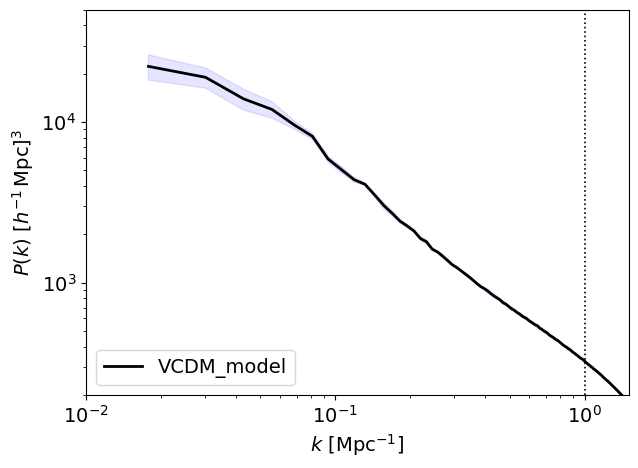

In [10]:
# Create figure
fig, axes = plt.subplots(figsize=(7, 5))

####################################################
axes.set_ylabel(r'$P(k)\ [h^{-1}\,{\rm Mpc}]^3$', fontsize=14)
axes.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$', fontsize=14)
axes.set_xlim(1e-2, 1.5)
axes.set_ylim(2e2, 5e4)
axes.loglog(k_ref, Pk_cola_mean, linestyle='-', lw=2, color='black', label='VCDM_model') #actually is Pk_cola_mean
axes.fill_between(k_ref, Pk_cola_mean - Pk_cola_std, Pk_cola_mean + Pk_cola_std,
                 color='blue', alpha=0.1, zorder=1, rasterized=True)
axes.axvline(1.0, color='black', lw=1.2, ls=':')
axes.tick_params(axis='both', which='major', labelsize=14)
axes.legend(loc='lower left', fontsize=14)

####################################################

####################################################
plt.subplots_adjust(hspace=0)
#plt.savefig("Pk.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [4]:
# Model
model1 = 'LCDM'
model2 = 'VCDM'
# Realizations
realizations = [0,12,19,22,27]
BoxSize = 500
# Save espectra
Pk_cola_all_LCDM = []
Pk_cola_all_VCDM = []
k_ref_LCDM = None  # k-vector
k_ref_VCDM = None  # k-vector

for realization in realizations:
    print(f"Processing realization {realization}...")

    # --- Paths ---
    root_cola_LCDM = f'/Users/jose/project/MG-PICOLA-PUBLIC/output/{model1}'
    path_ICs_cola_LCDM = f"{root_cola_LCDM}/{model1}_{realization}/{model1}_{realization}_z9p000"
    path_snaps_cola_LCDM = f"{root_cola_LCDM}/{model1}_{realization}/{model1}_{realization}_z0p000"
    
    
    root_cola_VCDM = f'/Users/jose/project/MG-PICOLA-PUBLIC/output/{model2}'
    path_ICs_cola_VCDM = f"{root_cola_VCDM}/{model2}_{realization}/{model2}_{realization}_z9p000"
    path_snaps_cola_VCDM = f"{root_cola_VCDM}/{model2}_{realization}/{model2}_{realization}_z0p000"
    
    # --- Positions ---
    pos_i_cola_LCDM, pos_f_cola_LCDM = pkmod.sort_pos(path_ICs_cola_LCDM, path_snaps_cola_LCDM, Quijote=False)    
    pos_i_cola_VCDM, pos_f_cola_VCDM = pkmod.sort_pos(path_ICs_cola_VCDM, path_snaps_cola_VCDM, Quijote=False)
    
    # --- Power Espectra ---
    k_cola_LCDM, Pk_cola_LCDM = pkmod.Pk(path_to_snaps=path_snaps_cola_LCDM, Quijote=False)
    k_cola_VCDM, Pk_cola_VCDM = pkmod.Pk(path_to_snaps=path_snaps_cola_VCDM, Quijote=False)

    
    if k_ref_LCDM is None:
        k_ref_LCDM = k_cola_LCDM
    else:
        # If not, interpolate
        if not np.allclose(k_cola_LCDM, k_ref_LCDM):
            Pk_cola_LCDM = interp1d(k_cola_LCDM, Pk_cola_LCDM, bounds_error=False, fill_value="extrapolate")(k_ref_LCDM)    


    if k_ref_VCDM is None:
        k_ref_VCDM = k_cola_VCDM
    else:
        # If not, interpolate
        if not np.allclose(k_cola_VCDM, k_ref_VCDM):
            Pk_cola_VCDM = interp1d(k_cola_VCDM, Pk_cola_VCDM, bounds_error=False, fill_value="extrapolate")(k_ref_VCDM)   



    
    Pk_cola_all_LCDM.append(Pk_cola_LCDM)
    Pk_cola_all_VCDM.append(Pk_cola_VCDM)    
        
# --- Convert to arrays ---
Pk_cola_all_LCDM = np.array(Pk_cola_all_LCDM)
Pk_cola_all_VCDM = np.array(Pk_cola_all_VCDM)

# --- Averages ---
Pk_cola_mean_LCDM = np.mean(Pk_cola_all_LCDM, axis=0)
Pk_cola_mean_VCDM = np.mean(Pk_cola_all_VCDM, axis=0)

# --- Standard Deviations ---
Pk_cola_std_LCDM= np.std(Pk_cola_all_LCDM, axis=0)
Pk_cola_std_VCDM = np.std(Pk_cola_all_VCDM, axis=0)

Processing realization 0...
Processing realization 12...
Processing realization 19...
Processing realization 22...
Processing realization 27...


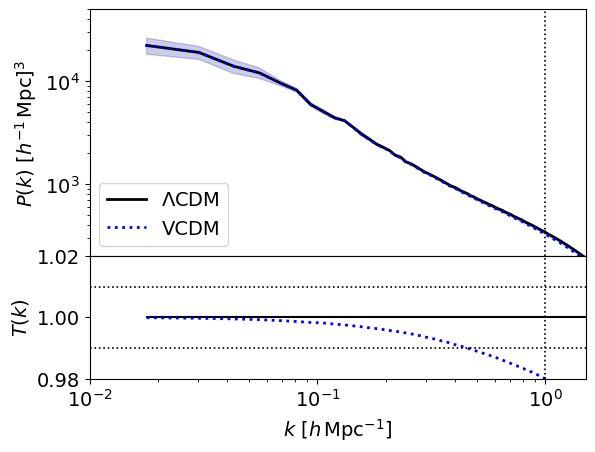

In [10]:
	
# Create figure
fig, axes = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})

####################################################
axes[0].set_ylabel(r'$P(k)\ [h^{-1}\,{\rm Mpc}]^3$', fontsize=14)
axes[0].set_xlim(1e-2, 1.5)
axes[0].set_ylim(2e2, 5e4)
axes[0].loglog(k_ref_LCDM, Pk_cola_mean_LCDM, linestyle='-', lw=2, color='black', label='$\Lambda$CDM')
axes[0].fill_between(k_ref_LCDM, Pk_cola_mean_LCDM - Pk_cola_std_LCDM, Pk_cola_mean_LCDM + Pk_cola_std_LCDM,
                 color='black', alpha=0.1, zorder=1, rasterized=True)
axes[0].loglog(k_ref_VCDM, Pk_cola_mean_VCDM, linestyle=':', lw=2, color='blue', label='VCDM')
axes[0].fill_between(k_ref_VCDM, Pk_cola_mean_VCDM - Pk_cola_std_VCDM, Pk_cola_mean_VCDM + Pk_cola_std_VCDM,
                 color='blue', alpha=0.1, zorder=1, rasterized=True)
axes[0].axvline(1.0, color='black', lw=1.2, ls=':')
axes[0].tick_params(axis='both', which='major', labelsize=14)
axes[0].legend(loc='lower left', fontsize=14)

####################################################
axes[1].set_xlim(1e-2, 1.5)
axes[1].set_ylim(0.98, 1.02)
axes[1].set_xlabel(r'$k\ [h\,{\rm Mpc}^{-1}]$', fontsize=14)
axes[1].set_ylabel(r'$T(k)$', fontsize=14)
axes[1].semilogx(k_ref_LCDM, np.ones(len(k_ref_LCDM)), '-', color='black')
axes[1].semilogx(k_ref_LCDM, np.sqrt(Pk_cola_mean_VCDM/Pk_cola_mean_LCDM), linestyle=':', lw=2, color='blue')
axes[1].axvline(1.0, color='black', lw=1.2, ls=':')
axes[1].axhline(1.01, color='k', lw=1.2, ls=':')
axes[1].axhline(0.99, color='k', lw=1.2, ls=':')
axes[1].tick_params(axis='both', which='major', labelsize=14)

####################################################
plt.subplots_adjust(hspace=0)
#plt.savefig("Pk.pdf", format="pdf", bbox_inches="tight")
plt.show()